# Calcul de coefficients de polarisation

In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from ipysigma import Sigma
import networkx as nx

In [6]:
with open('Q174606.pickle', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

dico_periods = {}
for node in G.nodes():
    period = node.get_era()
    if period not in dico_periods:
        dico_periods[period] = [node]
    else:
        dico_periods[period].append(node)
del dico_periods['Unknown']

file = "Graphe"

In [30]:
with open('merged_compo_filtered_graph.pickle', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

# dico_periods = {}
# for node in G.nodes():
#     period = node.get_era()
#     if period not in dico_periods:
#         dico_periods[period] = [node]
#     else:
#         dico_periods[period].append(node)
# del dico_periods['Unknown']

file = "Graphe"

In [8]:
import math
def prepare_sigma_with_composer_ids(original_graph):
    """Relabels a graph using Composer.id as node labels and returns a Sigma widget. The new sigma compatible graph is named graph and returned by the function"""
    #id_map = {node: int(node.id.replace('Q','')) for node in original_graph.nodes()}
    id_map={node: str(node)+" - "+str(node.id) for node in original_graph.nodes()}
    graph = nx.relabel_nodes(original_graph, id_map)
    #for node in original_graph.nodes(data=True) :
    #    print("og",node)

    # Clean all node/edge attributes to make sure they're JSON serializable because the composer object was not accepted by ipysigma
    for n, d in graph.nodes(data=True):
        #print(n,d)
        for k, v in d.items():
            if not isinstance(v, (str, int, float, bool, type(None))):
                d[k] = str(v)
    
    for n in original_graph.nodes():
        graph.nodes[str(n)+" - "+str(n.id)]['source']=n.description
        graph.nodes[str(n)+" - "+str(n.id)]['periode']=n.get_era()

    for u, v, d in graph.edges(data=True):
        for k, val in d.items():
            if not isinstance(val, (str, int, float, bool, type(None))):
                d[k] = str(val)

    layout = {
        node: {
            "x": math.cos(i * 2 * math.pi / len(graph)),
            "y": math.sin(i * 2 * math.pi / len(graph)),
        }
        for i, node in enumerate(graph)
    }

    #pagerank_scores = nx.pagerank(graph)

    #for k, v in pagerank_scores.items():
    #    assert isinstance(v, (int, float)), f"Non-numeric pagerank for node {k}: {v}"
    #for u, v, d in g.edges(data=True):
    for u, v, d in graph.edges(data=True):
        if d.get("source") == "chroma":
            #graph[str(u)+" - "+str(u.id)][str(v)+" - "+str(v.id)]["color_edge"] = "#3498DB"  # Blue for chroma
            #graph[str(u)+" - "+str(u.id)][str(v)+" - "+str(v.id)]["source"]="chroma"
            graph[u][v]["color_edge"] = "#3498DB"  # Blue for chroma
            graph[u][v]["source"]="chroma"
        elif d.get("source") == "chroma and influ":
            graph[u][v]["color_edge"] ="#2ECC71"
            graph[u][v]["source"]="chroma and influ" #Green for influ and chroma (the edge was present in both graphs)
        else:
            graph[u][v]["color_edge"] = "#E74C3C"  # Red for only influ (or default)
            graph[u][v]["source"]="influ"

    sigma = Sigma(
        graph=graph,
        layout=layout,
        default_edge_type="curve",
        node_border_color_from="node",
        raw_edge_color="color_edge",
        label_font="cursive",
        node_size=graph.out_degree()#pagerank_scores
    )

    return graph,sigma

In [12]:
with open('merged_compo_filtered_graph.pickle', 'rb') as f:
    G = pickle.load(f)

G, sigma = prepare_sigma_with_composer_ids(G)
sigma

Sigma(nx.DiGraph with 121 nodes and 2,343 edges)

In [16]:
import math

communautés = nx.algorithms.community.louvain_communities(G)
for i, commu in enumerate(communautés):
    for node in commu:
        G.nodes[node]['communauté'] = i

# Définir une colormap bleu-rouge pour les poids des arêtes
import matplotlib
import numpy as np
from IPython.display import Markdown
cmap = matplotlib.cm.get_cmap('coolwarm')
# Générer une couleur différente pour chaque communauté
import matplotlib.colors as mcolors

# Utiliser la meilleure partition trouvée précédemment
num_communities = len(communautés)
colors = list(mcolors.TABLEAU_COLORS.values())
if num_communities > len(colors):
    # Générer plus de couleurs si besoin
    cmap_communities = matplotlib.cm.get_cmap('tab20', num_communities)
    colors = [matplotlib.colors.rgb2hex(cmap_communities(i)) for i in range(num_communities)]

for node in G.nodes():
    G.nodes[node]['color'] = colors[G.nodes[node]['communauté']]

partitions = {"Medieval":[],"Baroque":[], "Classique":[], "Romantique":[], "XXe":[], "contemporain":[],"Unknown":[]}

for node in G.nodes:
    era = G.nodes[node]['periode']  # Default to "medium"
    #graph.nodes[str(node)+" - "+str(node.id)]["color_node"] = color.get(era, "#95A5A6")  # Gray if unknown
    #g.nodes[node]["size"] = 10  # Set a default size
    #partitions[era].append(graph.nodes[str(node)+" - "+str(node.id)])
    partitions[era].append(node)


for source, target in G.edges:
    G.edges[source, target]["color_edge"] = G.nodes[target]["color"]

layout = {}

# Grid positions for each era cluster center
grid_positions = {
    "Medieval": (0, 0),
    "Baroque": (-3, 0),
    "Classique": (0, 2),
    "Romantique": (3, 0),
    "XXe": (-2, -2),
    "contemporain": (2, -2)
}

# Assign circular layouts within each cluster
for era, node_names in partitions.items():
    base_x, base_y = grid_positions.get(era, (0, 0))
    angle_step = 2 * np.pi / max(1, len(node_names))
    radius = 1.5  # Distance from center of cluster

    for i, node_name in enumerate(node_names):
        angle = i * angle_step
        layout[node_name] = {
            "x": base_x + radius * np.cos(angle),
            "y": base_y + radius * np.sin(angle)
        }

# Calcul d'un score de PageRank pour ajuster la taille des noeuds par exemple
pagerank_scores = G.out_degree(weight='weight')

# Visualisation avec ipysigma
sigma = Sigma(
    graph=G,
    raw_node_color="color",
    raw_edge_color="color_edge",
    layout=layout,
    node_label="nom complet",
    default_edge_type="curve",
    label_font="cursive",
    node_size=pagerank_scores,  # On peut également multiplier par un facteur si nécessaire
    default_node_label_color="white"
)

display(Markdown("## Graphe des influences entre compositeurs (seuil={}) avec {} communautés".format(0, len(communautés))))

# Pour afficher dans Jupyter Notebook (si ipysigma est intégré dans un widget)
sigma

/var/folders/6_/wjb9ddn965xckzzthm1x7rnr0000gn/T/ipykernel_34044/3956888312.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('coolwarm')


## Graphe des influences entre compositeurs (seuil=0) avec 8 communautés

Sigma(nx.DiGraph with 121 nodes and 2,343 edges)

In [12]:
with open('graph_euclidian_seuil=0.65_communautés.pickle', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

dico_periods = {}
for node in G.nodes():
    communaute = G.nodes[node]['communauté']
    if communaute not in dico_periods:
        dico_periods[communaute] = [node]
    else:
        dico_periods[communaute].append(node)

file = "Chroma"

In [13]:
from IPython.display import Markdown, display

markdown_table = "| Communauté | Noeuds |\n|---|---|\n"
for comm in sorted(dico_periods.keys()):
    markdown_table += f"| {comm} | {' -- '.join(dico_periods[comm])} |\n"

display(Markdown(markdown_table))

| Communauté | Noeuds |
|---|---|
| 0 | Antheil; George -- Bartok; Bela -- Britten; Benjamin -- Hindemith; Paul -- Schoenberg; Arnold -- Shostakovich; Dmitri -- Stravinsky; Igor -- Weill; Kurt |
| 1 | Bach; Johann Sebastian -- Dussek; Jan Ladislav -- Giustini; Lodovico -- Scarlatti; Domenico -- Sibelius; Jean |
| 2 | Bach; Johann Christian -- Stamitz; Johann |
| 3 | Bruckner; Anton |
| 4 | Couperin; Francois |
| 5 | Beethoven; Ludwig van -- Berlioz; Hector -- Dvorak; Antonin -- Haydn; Joseph -- Mozart; Wolfgang Amadeus -- Smetana; Bedrich -- Verdi; Giuseppe -- Weber; Carl Maria von |
| 6 | Borodin; Alexander -- Brahms; Johannes -- Chopin; Frederic -- Debussy; Claude -- Faure; Gabriel -- Liszt; Franz -- Ravel; Maurice -- Schubert; Franz -- Wagner; Richard |
| 7 | Lully; Jean-Baptiste |
| 8 | Berg; Alban -- Boulez; Pierre -- Messiaen; Olivier -- Webern; Anton |
| 9 | Albinoni; Tomaso -- Boccherini; Luigi Rodolofo -- Cimarosa; Domenico -- Clementi; Muzio -- Corelli; Arcangelo -- Handel; George Frederic -- Haydn; Johann Michael -- Mozart; Leopold -- Pleyel; Ignace Joseph -- Salieri; Antonio -- Telemann; Georg Philipp -- Vivaldi; Antonio |
| 10 | Mussorgsky; Modest |
| 11 | Purcell; Henry |
| 12 | Rameau; Jean-Phillipe |
| 13 | Mahler; Gustav -- Milhaud; Darius -- Prokofiew; Sergej -- Rimsky-Korsakov; Nicolai -- Rossini; Gioacchino -- Strauss; Richard -- Tchaikovsky; Peter Iljitsch |
| 14 | Platti; Giovanni Benedetto -- Saint-Saens; Camille |
| 15 | Bach; Carl Philipp Emanuel -- Grieg; Edvard -- Ives; Charles Edward -- Mendelssohn-Bartholdy; Felix -- Schumann; Clara -- Schumann; Robert |
| 16 | Varese; Edgar |


## Version proposée par l'article "A Measure of Polarization on Social MediaNetworks Based on Community Boundaries"

In [14]:
def polarization_coefficient(period1,period2):
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    subgraph = G.subgraph(nodes1 + nodes2)
    B12 = set()
    B21 = set()
    I1 = set(nodes1)
    I2 = set(nodes2)
    for u in nodes1:
        for v in nodes2:
            if G.has_edge(u,v):
                B12.add(u)
                B21.add(v)
    I1 = I1 - B12
    I2 = I2 - B21
    s = 0
    for v in B12:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I1:
                di += 1
            elif w in B21:
                db += 1
        s += (di/(di+db)) - 0.5
    for v in B21:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I2:
                di += 1
            elif w in B12:
                db += 1
        s += (di/(di+db)) - 0.5
    if len(B12) + len(B21) == 0:
        return -1
    return s / (len(B12) + len(B21))

Text(0.5, 1.0, 'Coefficient de polarisation par la frontière entre les périodes')

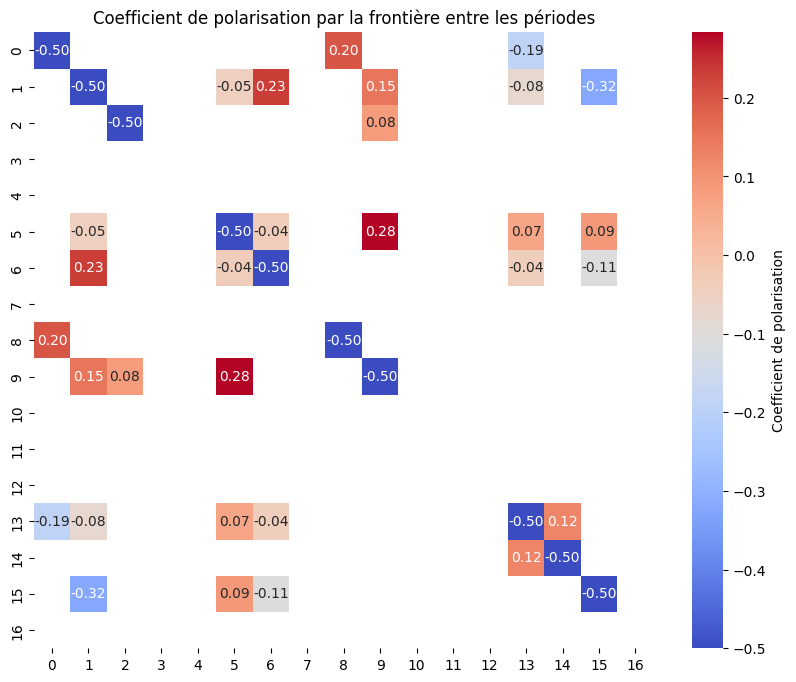

In [15]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = sorted(list(dico_periods.keys()))
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient(periods[i], periods[j])
plt.figure(figsize=(10, 8))
mask = (matrix ==-1)
sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=periods, yticklabels=periods, cmap='coolwarm', mask = mask, cbar_kws={'label': 'Coefficient de polarisation'})
plt.title('Coefficient de polarisation par la frontière entre les périodes')

## Test de Fisher exact

In [16]:
from itertools import combinations
from scipy.stats import fisher_exact, chi2_contingency

In [17]:
def polarization_coefficient_fisher(period1, period2):
    """Utilise le teste de Fisher pour calculer le coefficient de polarisation entre deux périodes.
    H0 : En proportion, il y a autant de liens entre les deux périodes qu'à l'intérieur de chaque période."""
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    edges_AA = sum(1 for u, v in combinations(nodes1, 2) if G.has_edge(u, v))
    edges_BB = sum(1 for u, v in combinations(nodes2, 2) if G.has_edge(u, v))
    total_internal_edges = edges_AA + edges_BB

    inter_edges = sum(1 for u in nodes1 for v in nodes2 if G.has_edge(u, v))

    # Paires possibles
    total_internal_pairs = len(nodes1) * (len(nodes1) - 1) // 2 + \
                            len(nodes2) * (len(nodes2) - 1) // 2
    total_inter_pairs = len(nodes1) * len(nodes2)

    non_edges_internal = total_internal_pairs - total_internal_edges
    non_edges_inter = total_inter_pairs - inter_edges

    # Tableau 2x2
    table = np.array([
        [total_internal_edges, inter_edges],
        [non_edges_internal,   non_edges_inter]
    ])
    #print(table)
    res = fisher_exact(table, alternative="greater")
    return res.statistic

Text(0.5, 1.0, 'Coefficient de polarisation par test de Fisher')

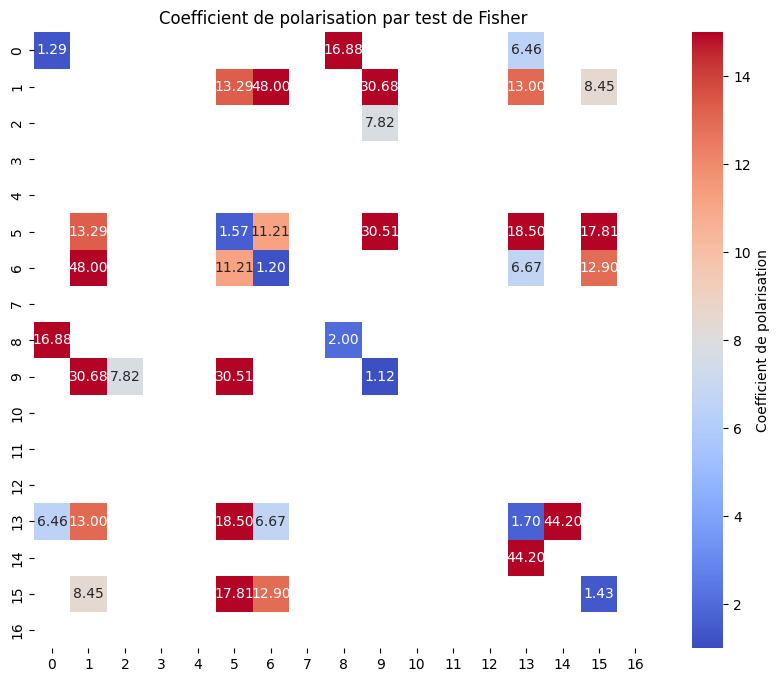

In [18]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = sorted(list(dico_periods.keys()))
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient_fisher(periods[i], periods[j])
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    xticklabels=periods,
    yticklabels=periods,
    cmap='coolwarm',
    vmin=1,
    vmax=15,
    cbar_kws={'label': 'Coefficient de polarisation'}
)
plt.title('Coefficient de polarisation par test de Fisher')

### Un test alternatif : le test de Chi-2

In [19]:
def polarization_coefficient_chi2(period1, period2):
    """Utilise le teste de Fisher pour calculer le coefficient de polarisation entre deux périodes.
    H0 : En proportion, il y a autant de liens entre les deux périodes qu'à l'intérieur de chaque période."""
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    edges_AA = sum(1 for u, v in combinations(nodes1, 2) if G.has_edge(u, v))
    edges_BB = sum(1 for u, v in combinations(nodes2, 2) if G.has_edge(u, v))
    total_internal_edges = edges_AA + edges_BB

    inter_edges = sum(1 for u in nodes1 for v in nodes2 if G.has_edge(u, v))

    # Paires possibles
    total_internal_pairs = len(nodes1) * (len(nodes1) - 1) // 2 + \
                            len(nodes2) * (len(nodes2) - 1) // 2
    total_inter_pairs = len(nodes1) * len(nodes2)

    non_edges_internal = total_internal_pairs - total_internal_edges
    non_edges_inter = total_inter_pairs - inter_edges

    # Tableau 2x2
    table = np.array([
        [total_internal_edges, inter_edges],
        [non_edges_internal,   non_edges_inter]
    ])
    #print(table)
    res = chi2_contingency(table)
    return res.statistic

Text(0.5, 1.0, 'Coefficient de polarisation par test du Chi2')

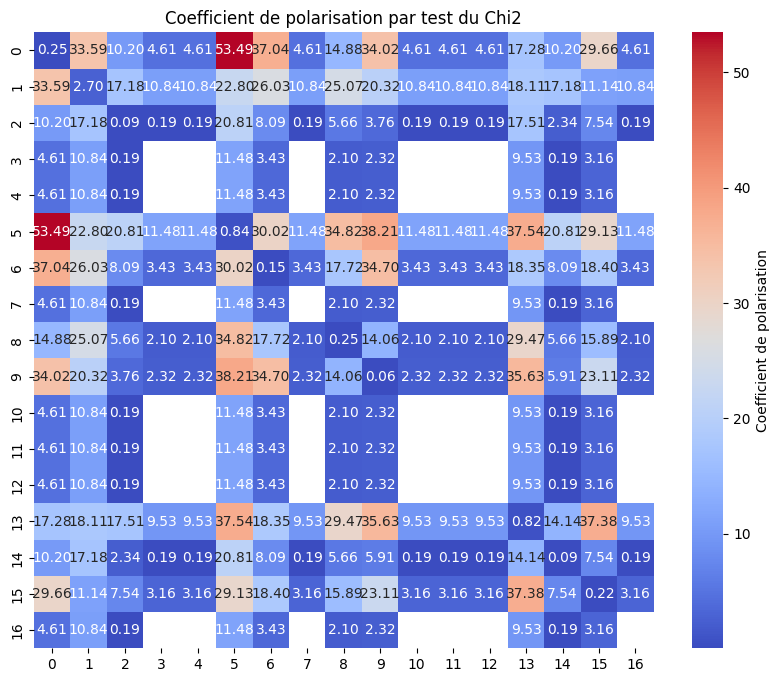

In [23]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = sorted(list(dico_periods.keys()))
for i in range(len(periods)):
    for j in range(len(periods)):
            try:
                matrix[i][j] = polarization_coefficient_chi2(periods[i], periods[j])
            except:
                matrix[i][j] = -1.
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    xticklabels=periods,
    yticklabels=periods,
    cmap='coolwarm',
    mask=(matrix == -1),
    cbar_kws={'label': 'Coefficient de polarisation'}
)
plt.title('Coefficient de polarisation par test du Chi2')